# Pneumonia Classification from Chest X-rays

**Computer Vision Assignment 2

Goal: Improve a baseline CNN to maximise accuracy, precision, and recall when classifying chest X-ray images as NORMAL or PNEUMONIA.

Dataset: Chest X-ray images train/test split provided

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Check GPU availability
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [11]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling
from tensorflow.keras.optimizers import Adam

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [12]:
# Dataset paths - UPDATE THESE to match your Google Drive structure
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'
# Hyperparameters (from lecturer's baseline script)
BATCH_SIZE = 12
EPOCHS = 8
IMG_HEIGHT = 128
IMG_WIDTH  = 128
IMG_CHANNELS = 3

In [13]:
# Load training data with 80/20 train/val split
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

# Load test data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    seed=None,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class names: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of classes: 3


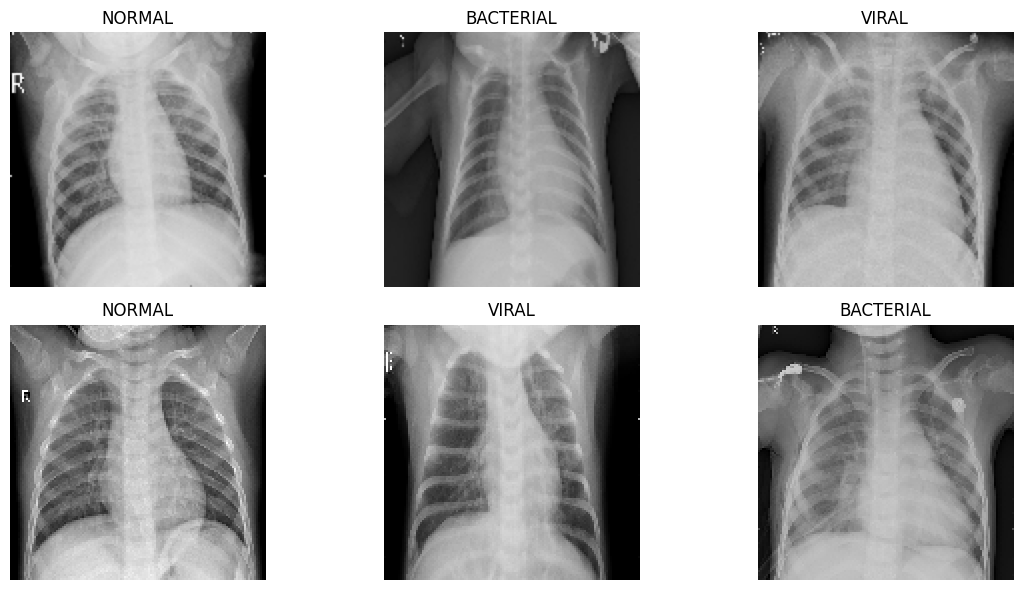

In [14]:
# Display a few sample images from the training set
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# Build the baseline CNN
model = Sequential([
    Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,227,651 (12.31 MB)

 Trainable params: 3,227,651 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train and measure training time
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print(f'\nTraining completed in {training_time:.1f} seconds ({training_time/60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.7322 - loss: 0.6354 - val_accuracy: 0.7729 - val_loss: 0.5346
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7793 - loss: 0.5127

In [ ]:
# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Collect all predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# Overall test accuracy
test_accuracy = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print()

In [ ]:
# Per-class precision, recall, F1
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# Show predictions on a few test images
test_batch = test_ds.take(1)
plt.figure(figsize=(12, 6))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))

        # Make prediction
        prediction = model.predict(tf.expand_dims(images[i], 0), verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        true_class = class_names[labels[i].numpy()]
        confidence = 100 * np.max(prediction)

        plt.title(f'True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)')
        plt.axis('off')
plt.tight_layout()
plt.show()